In [1]:
!unzip /content/balanced_dataset.zip -d /content/

Archive:  /content/balanced_dataset.zip
   creating: /content/balanced_dataset/
  inflating: /content/balanced_dataset/data.yaml  
   creating: /content/balanced_dataset/test/
   creating: /content/balanced_dataset/test/images/
  inflating: /content/balanced_dataset/test/images/DJI-00760-00023_jpg.rf.4676d5ab012ce14ea6d34d8ca8668fdc.jpg  
  inflating: /content/balanced_dataset/test/images/DJI_0005-0118_jpg.rf.c9d0192422125e20a5d954e24906d004.jpg  
  inflating: /content/balanced_dataset/test/images/DJI_0005-0166_jpg.rf.1c633e5801ad32ccf244361677bbae9e.jpg  
  inflating: /content/balanced_dataset/test/images/DJI_0005-0175_jpg.rf.69f4716816fbe8f11bbe8f2c9b7e5bfb.jpg  
  inflating: /content/balanced_dataset/test/images/DJI_0005-0176_jpg.rf.2e57b6f94f44434fd25f006900cbb1c2.jpg  
  inflating: /content/balanced_dataset/test/images/DJI_0014_JPG.rf.2d3ffe9d6be73695e18cdc237e8dc00e.jpg  
  inflating: /content/balanced_dataset/test/images/DJI_0019_JPG.rf.d75f44654656852da6f1c312abf57024.jpg  
  i

In [4]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.5 MB/s eta 0:00:00


In [15]:
from ultralytics import YOLO
model = YOLO("yolov8n.pt")

In [16]:
model.train(
        data="balanced_dataset/data.yaml",
        epochs=40,
        imgsz=640,
        batch=16,
        scale=0.4,


        degrees=15.0,
        flipud=0.2,
        fliplr=0.2,

    )

Ultralytics 8.4.24 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=balanced_dataset/data.yaml, degrees=15.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.2, flipud=0.2, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train6, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7a0f7813a510>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0

Для тренування було обрано 40 епох. Це оптимальне значення для даного датасету, оскільки об'єкти є дрібними та мають обмежену кількість візуальних ознак для вивчення. Аналізуючи графіки метрик, можна зробити висновок, що модель ще має певний запас для навчання, проте потенційний незначний приріст точності, як на мене, не виправдовує додаткових витрат часу.

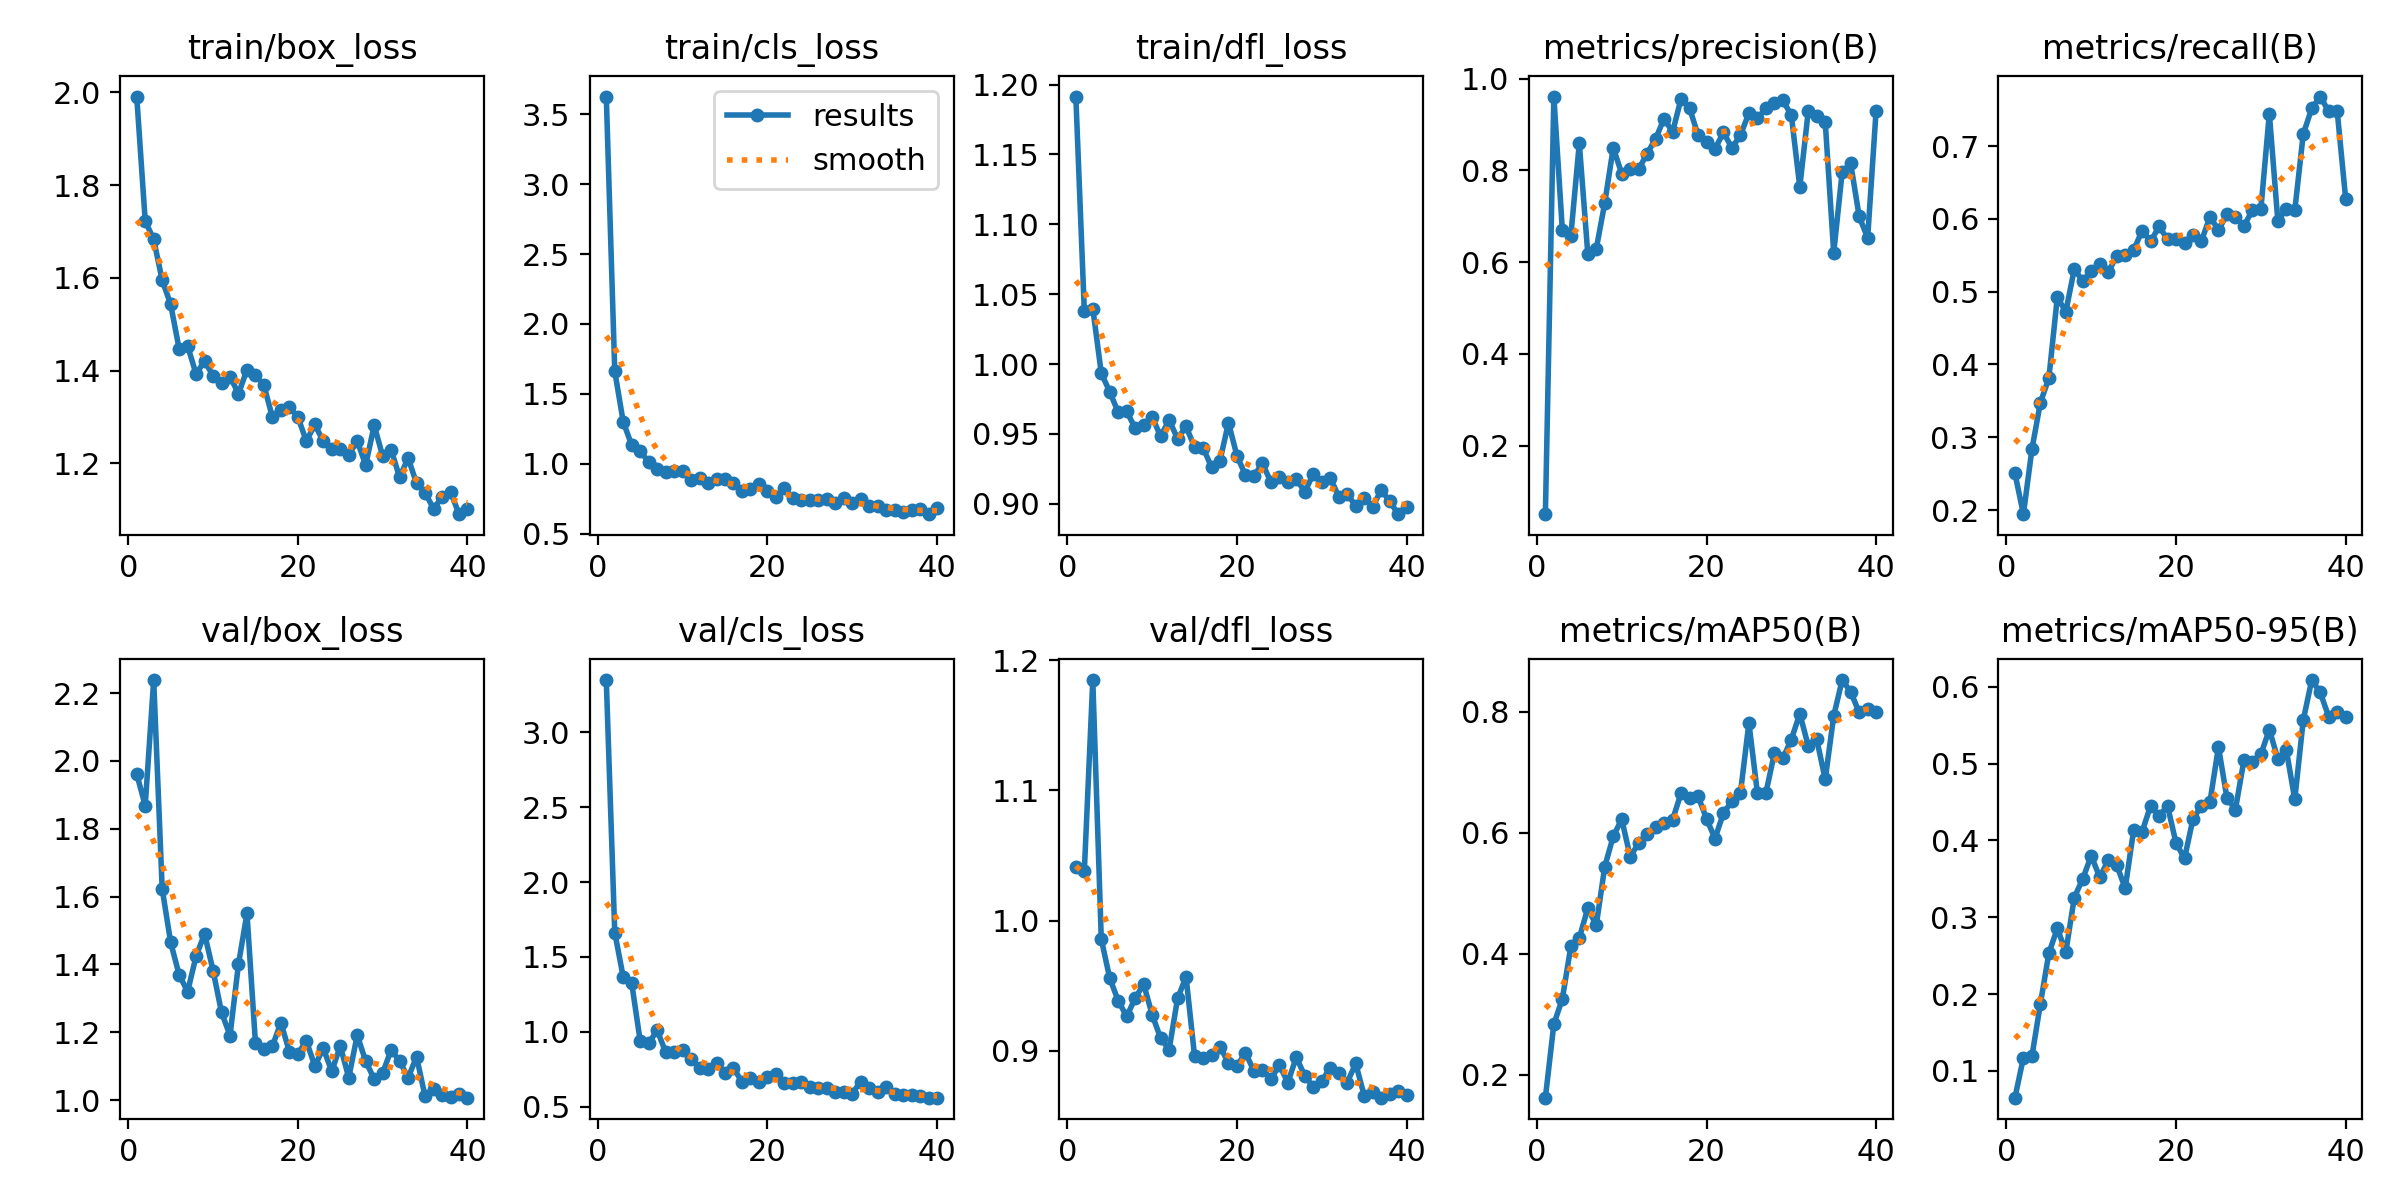

In [20]:
from IPython.display import Image
Image(filename='/content/runs/detect/train6/results.png')

Аналізуючи графіки видно наступне:
1. Стабільне падіння loss-функції (на val та test), що свідчить про відсутність перенавчання.
2. Зростання precision та recall. Precision майже одразу досягає високих значень, скоріш за все пов'язано з тим, що клас "car" домінує в датасеті. Recall зростає рівніше, видно, що модель поступово вчиться розпізнавати реальні об'єкти.
3. mAP стабільно ростуть, оскільки вони не зупиняються на одному значенні, модель ще має запас для тренування.